#### Import

In [1]:
import sys
import torch
sys.path.insert(0, '..')
from src.gnn.seed import set_seed
from src.gnn.data import load_and_preprocess_data
from src.gnn.training import compute_class_weights, train_with_early_stopping, print_test_evaluation
from src.gnn.visualization import plot_learning_curves
from src.gnn.losses import FocalLoss
from src.gnn.models import GAT

#### Seed

In [2]:
set_seed(42)

#### Load data

In [3]:
data, device = load_and_preprocess_data('../data/processed/pyg_data.pt', undirected=False)

Device: cpu
Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])


#### Define model

In [ ]:
model = GAT(
    in_channels=data.x.shape[1], 
    hidden_channels=64,
    out_channels=2, 
    heads=2,
    dropout=0.5
).to(device)

print(model)

GAT(
  (conv1): GATv2Conv(165, 32, heads=4)
  (conv2): GATv2Conv(128, 2, heads=1)
)


#### Focal Loss and Optimizer

In [5]:
weight = compute_class_weights(data, device)

criterion = FocalLoss(weight=weight, gamma=2.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)

Class weights: licit=1.00, illicit=2.86


#### Training loop

In [6]:
history = train_with_early_stopping(
    model=model, 
    data=data, 
    optimizer=optimizer, 
    criterion=criterion, 
    save_path='../saved_models/gat_best.pt', 
    num_epochs=200, 
    patience=20
)

Epoch 001: Train Loss=1.1141, Train F1=0.3805, Val F1=0.4044, Gap=-0.0239
Epoch 002: Train Loss=1.2054, Train F1=0.4306, Val F1=0.4039, Gap=0.0267
Epoch 003: Train Loss=0.6952, Train F1=0.4877, Val F1=0.4156, Gap=0.0720
Epoch 004: Train Loss=0.6096, Train F1=0.5196, Val F1=0.4327, Gap=0.0869
Epoch 005: Train Loss=0.5373, Train F1=0.5389, Val F1=0.4428, Gap=0.0960
Epoch 006: Train Loss=0.4456, Train F1=0.5503, Val F1=0.4428, Gap=0.1075
Epoch 007: Train Loss=0.4618, Train F1=0.5469, Val F1=0.4399, Gap=0.1069
Epoch 008: Train Loss=0.4466, Train F1=0.5207, Val F1=0.4325, Gap=0.0881
Epoch 009: Train Loss=0.4240, Train F1=0.5024, Val F1=0.4272, Gap=0.0752
Epoch 010: Train Loss=0.3918, Train F1=0.4945, Val F1=0.4244, Gap=0.0701
Epoch 011: Train Loss=0.3708, Train F1=0.4932, Val F1=0.4239, Gap=0.0693
Epoch 012: Train Loss=0.3444, Train F1=0.4966, Val F1=0.4260, Gap=0.0706
Epoch 013: Train Loss=0.3296, Train F1=0.4996, Val F1=0.4273, Gap=0.0724
Epoch 014: Train Loss=0.3182, Train F1=0.5022, Val

#### Learning curve

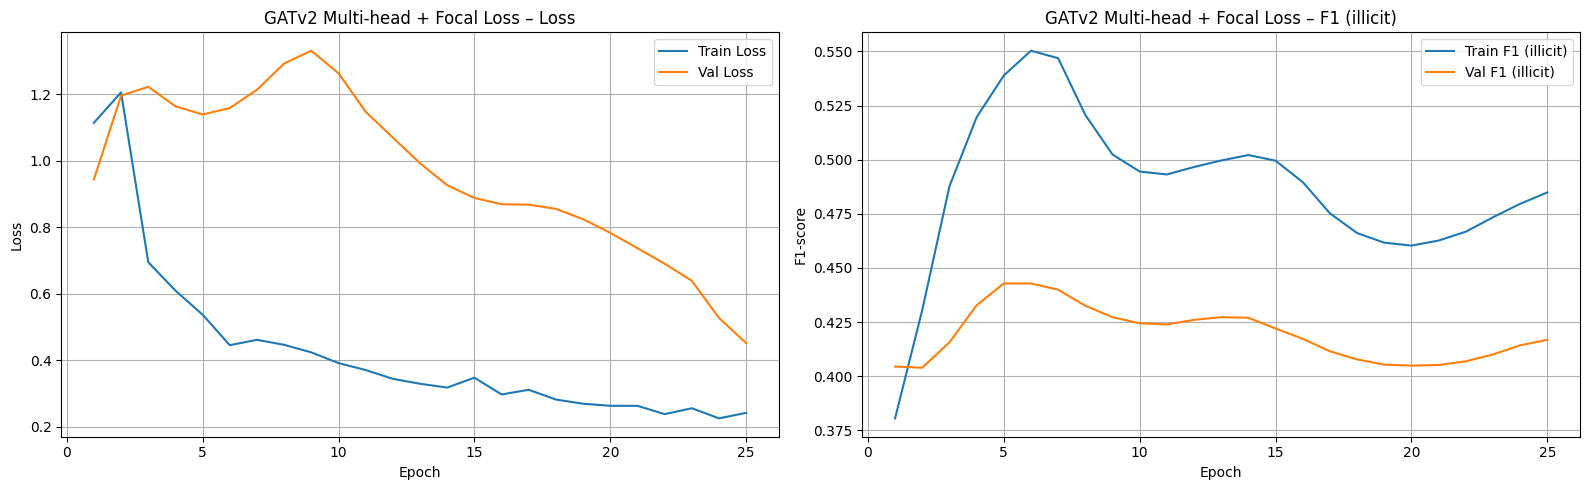

In [7]:
plot_learning_curves(history, model_name="GATv2 Multi-head + Focal Loss")

#### Test evaluation

In [8]:
model.load_state_dict(torch.load('../saved_models/gat_best.pt'))
print_test_evaluation(model, data, criterion, label="GAT Test")

 GAT Test Set Evaluation
  Loss          : 1.0448
  Accuracy      : 0.5086
  Precision(ill): 0.1053
  Recall(ill)   : 0.8753
  F1(illicit)   : 0.1880
  F1(macro)     : 0.4179
  AUC-PR        : 0.2291

Classification Report:
              precision    recall  f1-score   support

   Licit (0)     0.9824    0.4832    0.6477     15587
 Illicit (1)     0.1053    0.8753    0.1880      1083

    accuracy                         0.5086     16670
   macro avg     0.5438    0.6793    0.4179     16670
weighted avg     0.9254    0.5086    0.6179     16670

Confusion Matrix:
[[7531 8056]
 [ 135  948]]
